## Setup


In [2]:
"""
Implementation based on: 
- In-Class Notes 13: Convolutional Neural Networks and Image Classification
"""


import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Load Data


In [3]:
full = pd.read_csv('ipologists/data/final/dataset_full.csv')
risk = pd.read_csv('ipologists/data/final/dataset_with_risk.csv')
print(f"Full Dataset: {full.shape}")
print(f"Risk Dataset: {risk.shape}")

Full Dataset: (6110, 24)
Risk Dataset: (862, 28)


## Preprocessing

In [4]:
features = ['Offer Size (M)', 'Offer Price', 'Initial Pub Offer (Shares Offered)',
    'Market Cap at Offer (M)', 'offer_size_to_mktcap', 'has_bulge_bracket',
    'vix', 'nasdaq', 'fed_funds', 'treasury_10y', 'cpi',
    'unemployment', 'gdp', 'ipo_volume', 'market_return_1m'
]

risk_features = features + ['regulatory_risk', 'competitive_risk', 'financial_risk', 'overall_risk']

def preprocess (df, features, target):
  df = df.dropna(subset=[target]).copy()
  X = df[features].copy()
  y= df[target].values
  X = X.fillna(X.median())
  scaler = StandardScaler()
  X_scaled = scaler.fit_transform(X)
  return X_scaled, y, scaler

X_full, y_full, scaler_full = preprocess(full, features, 'underpriced')
X_risk, y_risk, scaler_risk = preprocess(risk, risk_features, 'underpriced')

print(f"Full dataset X shape: {X_full.shape}, and has underpriced rate: {y_full.mean():.2%}")
print(f"Risk dataset X shape: {X_risk.shape}, and has underpriced rate: {y_risk.mean():.2%}")


Full dataset X shape: (6110, 15), and has underpriced rate: 60.05%
Risk dataset X shape: (862, 19), and has underpriced rate: 65.08%


Making our 3-class target


In [5]:
def three_class(df):
  df = df.dropna(subset=['Offer To 1st Close']).copy()
  thresholds = [ df['Offer To 1st Close'] < 0, (df['Offer To 1st Close'] >= 0) & (df['Offer To 1st Close'] <= 20),df['Offer To 1st Close'] > 20]
  df['three_class'] = np.select(thresholds, [0,1,2])
  return df

full_3classes = three_class(full)
risk_3classes = three_class(risk)
X_full_3c, y_full_3c, _ = preprocess(full_3classes, features, 'three_class')

counts = pd.Series(y_full_3c).value_counts().sort_index()
labels = ['Overpriced (<0%)', 'Mild (0-20%)', 'Strong (>20%)']
print("3-class distribution:")
for i, (label, count) in enumerate(zip(labels, counts)):
    print(f"  {label}: {count} ({count/len(y_full_3c):.1%})")


3-class distribution:
  Overpriced (<0%): 1234 (22.0%)
  Mild (0-20%): 3178 (56.6%)
  Strong (>20%): 1201 (21.4%)


## Neural Network Architecture


In [6]:
class NeuralNetwork(nn.Module):
  def __init__(self, input_dim, num_classes=2, hidden_dim= 128):
    super().__init__()
    self.pipeline= torch.nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.BatchNorm1d(hidden_dim),
        nn.ReLU(),
        nn.Dropout(0.1),
        nn.Linear(hidden_dim, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.1),
        nn.Linear(64, num_classes)

    )
  def forward(self, X):
    return self.pipeline(X)

#Training & Evaluation


In [10]:
def make_loaders(X, y, batch_size=64):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

  X_train = torch.tensor(X_train, dtype=torch.float32)
  X_test = torch.tensor(X_test, dtype=torch.float32)
  y_train = torch.tensor(y_train, dtype=torch.long)
  y_test = torch.tensor(y_test, dtype=torch.long)

  train_dataset = TensorDataset(X_train, y_train)
  test_dataset = TensorDataset(X_test, y_test)

  train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle=True)
  test_loader = DataLoader(test_dataset, batch_size=batch_size)

  return train_loader, test_loader, y_test


def train_model(model, train_loader, epochs=100, lr=1e-3):
  model.to(device)
  opt = torch.optim.Adam(model.parameters(), lr = lr)
  loss = nn.CrossEntropyLoss()
  history = []

  for epoch in range(epochs):
    model.train()
    for X_batch, y_batch in train_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      opt.zero_grad()
      y_pred = model(X_batch)
      loss_value = loss(y_pred, y_batch)
      loss_value.backward()
      opt.step()
    history.append(loss_value.item())
    if epoch % 10 ==0:
      print(f"Epoch {epoch}, Loss: {loss_value.item():.4f}")
  return model,history

def evaluate(model, test_loader, y_test, class_names):
  model.eval()
  all_pred = []
  with torch.no_grad():
    for X_batch, _ in test_loader:
      preds = model(X_batch.to(device)).argmax(1).cpu().numpy()
      all_pred.extend(preds)

  print("Classification Report:")
  print(classification_report(y_test, all_pred, target_names=class_names))


  return all_pred


## Model 1: Binary Classifier on Full Dataset


Training Model 1: Binary — Full Dataset
Epoch 0, Loss: 0.5701
Epoch 10, Loss: 0.6729
Epoch 20, Loss: 0.5884
Epoch 30, Loss: 0.5250
Epoch 40, Loss: 0.8056
Epoch 50, Loss: 0.5721
Epoch 60, Loss: 0.6093
Epoch 70, Loss: 0.4699
Epoch 80, Loss: 0.5672
Epoch 90, Loss: 0.5742
Classification Report:
              precision    recall  f1-score   support

  Overpriced       0.79      0.19      0.30       488
 Underpriced       0.64      0.97      0.77       734

    accuracy                           0.66      1222
   macro avg       0.71      0.58      0.54      1222
weighted avg       0.70      0.66      0.58      1222



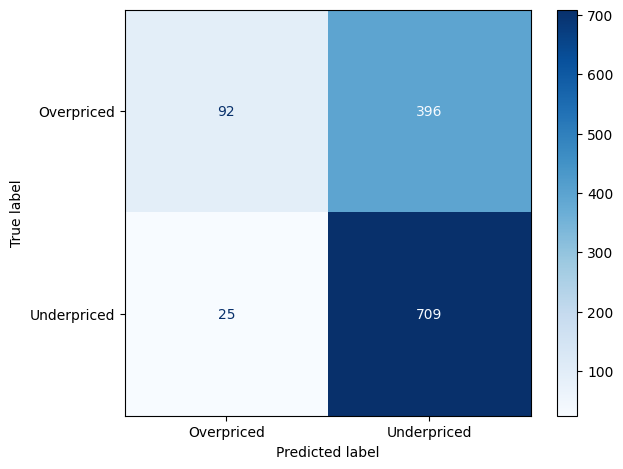

In [11]:

train_loader_1, test_loader_1, y_test_1 = make_loaders(X_full, y_full)
model_1 = NeuralNetwork(input_dim=X_full.shape[1], num_classes=2)
history_1 = train_model(model_1, train_loader_1, epochs=100)
preds_1 = evaluate(model_1, test_loader_1, y_test_1, ['Overpriced', 'Underpriced'])

## Model 2: Binary Classifier on Risk Dataset

Training Model 2: Binary — Risk Dataset
Epoch 0, Loss: 0.6195
Epoch 10, Loss: 0.4392
Epoch 20, Loss: 0.4570
Epoch 30, Loss: 0.4150
Epoch 40, Loss: 0.3944
Epoch 50, Loss: 0.2996
Epoch 60, Loss: 0.2797
Epoch 70, Loss: 0.1845
Epoch 80, Loss: 0.3327
Epoch 90, Loss: 0.2050
Classification Report:
              precision    recall  f1-score   support

  Overpriced       0.46      0.35      0.40        60
 Underpriced       0.69      0.78      0.73       113

    accuracy                           0.63       173
   macro avg       0.57      0.56      0.56       173
weighted avg       0.61      0.63      0.62       173



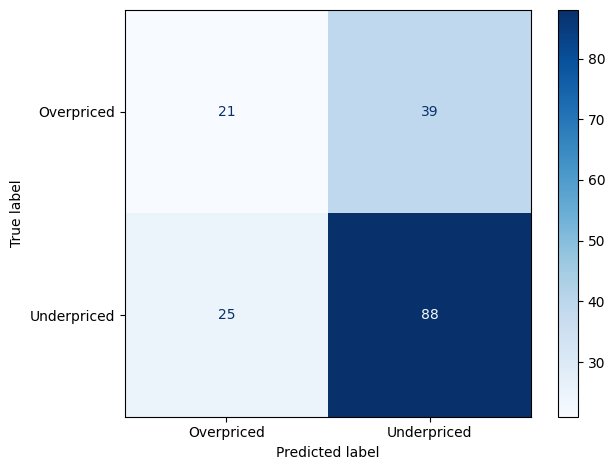

In [13]:
train_loader_2, test_loader_2, y_test_2 = make_loaders(X_risk, y_risk)
model_2 = NeuralNetwork(input_dim=X_risk.shape[1], num_classes=2)
history_2 = train_model(model_2, train_loader_2, epochs=100)
preds_2 = evaluate(model_2, test_loader_2, y_test_2, ['Overpriced', 'Underpriced'])

## Model 3: 3 Class Classifier on Full Dataset

Training Model 3: 3-Class — Full Dataset
Epoch 0, Loss: 0.9844
Epoch 10, Loss: 0.7486
Epoch 20, Loss: 0.9117
Epoch 30, Loss: 0.5147
Epoch 40, Loss: 0.7372
Epoch 50, Loss: 0.8454
Epoch 60, Loss: 0.7271
Epoch 70, Loss: 0.9551
Epoch 80, Loss: 0.6053
Epoch 90, Loss: 0.7174
Classification Report:
               precision    recall  f1-score   support

   Overpriced       0.45      0.17      0.24       247
 Mild (0-20%)       0.68      0.85      0.76       636
Strong (>20%)       0.57      0.55      0.56       240

     accuracy                           0.64      1123
    macro avg       0.57      0.52      0.52      1123
 weighted avg       0.61      0.64      0.60      1123



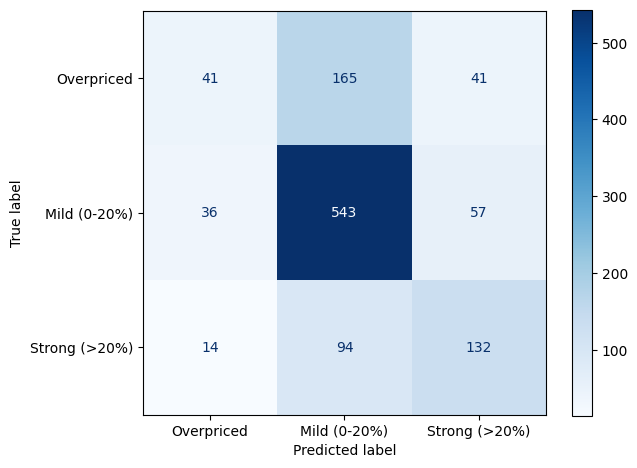

In [14]:
train_loader_3, test_loader_3, y_test_3 = make_loaders(X_full_3c, y_full_3c)
model_3 = NeuralNetwork(input_dim=X_full_3c.shape[1], num_classes=3)
history_3 = train_model(model_3, train_loader_3, epochs=100)
preds_3 = evaluate(model_3, test_loader_3, y_test_3,
                   ['Overpriced', 'Mild (0-20%)', 'Strong (>20%)'])